/home/saljaoui/piscine-ai/model-selection/ex00/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


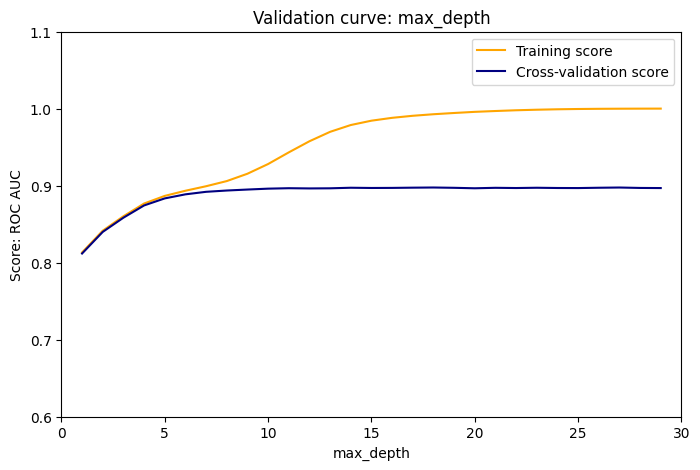

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import validation_curve
from sklearn.ensemble import RandomForestClassifier

X, y = make_classification(n_samples=100000,
                        n_features= 30,
                        n_informative=10,
                        flip_y=0.2 )


clf = RandomForestClassifier(random_state=42, n_jobs=-1)

param_range =  np.arange(1, 30) 

# 4. Compute validation curve
train_scores, test_scores = validation_curve(
    clf, X, y,
    param_name="max_depth",
    param_range=param_range,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

# 6. Plot
plt.figure(figsize=(8,5))
plt.plot(param_range, train_mean, color='orange', label='Training score')
plt.plot(param_range, test_mean, color='navy', label='Cross-validation score')
plt.xlim(0,30)
plt.ylim(0.6,1.1)
plt.title("Validation curve: max_depth")
plt.xlabel("max_depth")
plt.ylabel("Score: ROC AUC")
plt.legend(loc="best")
plt.show()

/home/saljaoui/piscine-ai/model-selection/ex00/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


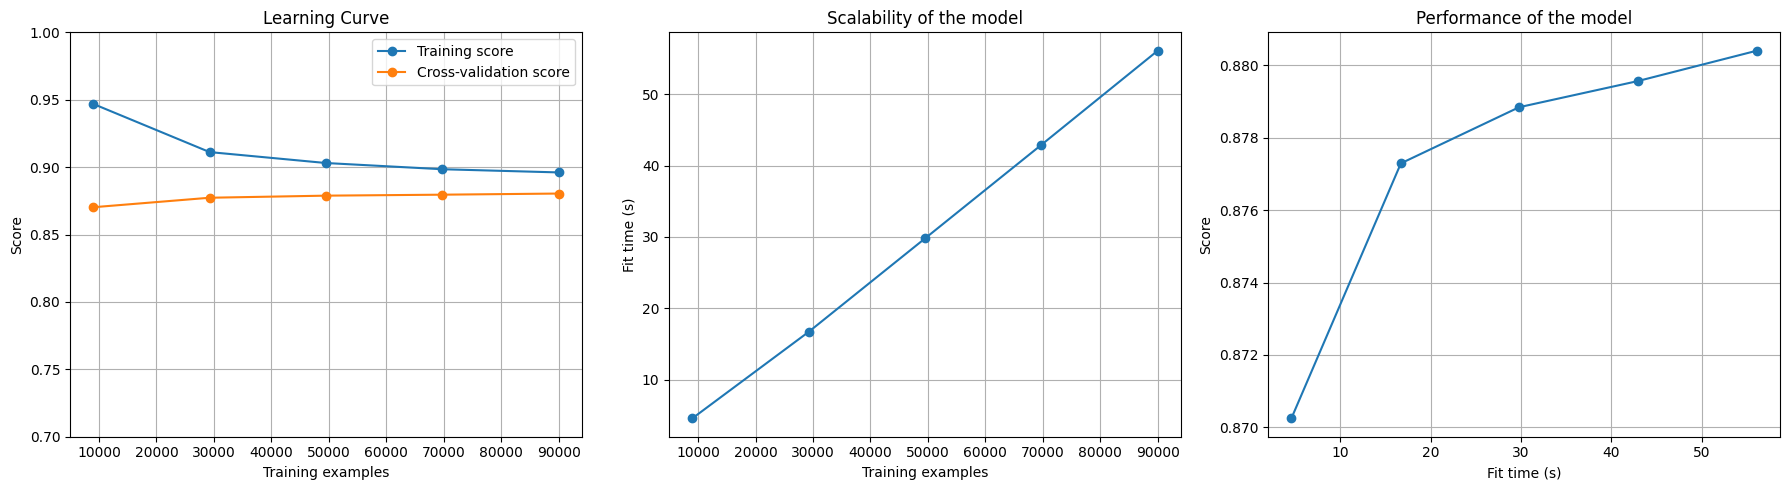

In [2]:
from sklearn.model_selection import learning_curve

clf = RandomForestClassifier(max_depth=12)

train_sizes, train_scores, test_scores, fit_times, _ = learning_curve(
    clf,
    X,
    y,
    cv=10,
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5),
    return_times=True
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)
fit_mean = fit_times.mean(axis=1)

# Plots
plt.figure(figsize=(18, 5))

# Learning curve
plt.subplot(1, 3, 1)
plt.plot(train_sizes, train_mean, 'o-', label="Training score")
plt.plot(train_sizes, test_mean, 'o-', label="Cross-validation score")
plt.xlabel("Training examples")
plt.ylabel("Score")
plt.title("Learning Curve")
plt.legend()
plt.ylim(0.7, 1.0)
plt.grid(True)

# Scalability
plt.subplot(1, 3, 2)
plt.plot(train_sizes, fit_mean, 'o-')
plt.xlabel("Training examples")
plt.ylabel("Fit time (s)")
plt.title("Scalability of the model")
plt.grid(True)

# Performance
plt.subplot(1, 3, 3)
plt.plot(fit_mean, test_mean, 'o-')
plt.xlabel("Fit time (s)")
plt.ylabel("Score")
plt.title("Performance of the model")
plt.grid(True)

plt.tight_layout()
plt.show()
